In [413]:
import numpy as np
import matplotlib.pyplot as plt

# spherical harmonics
from scipy.special import sph_harm_y

(4, 4)


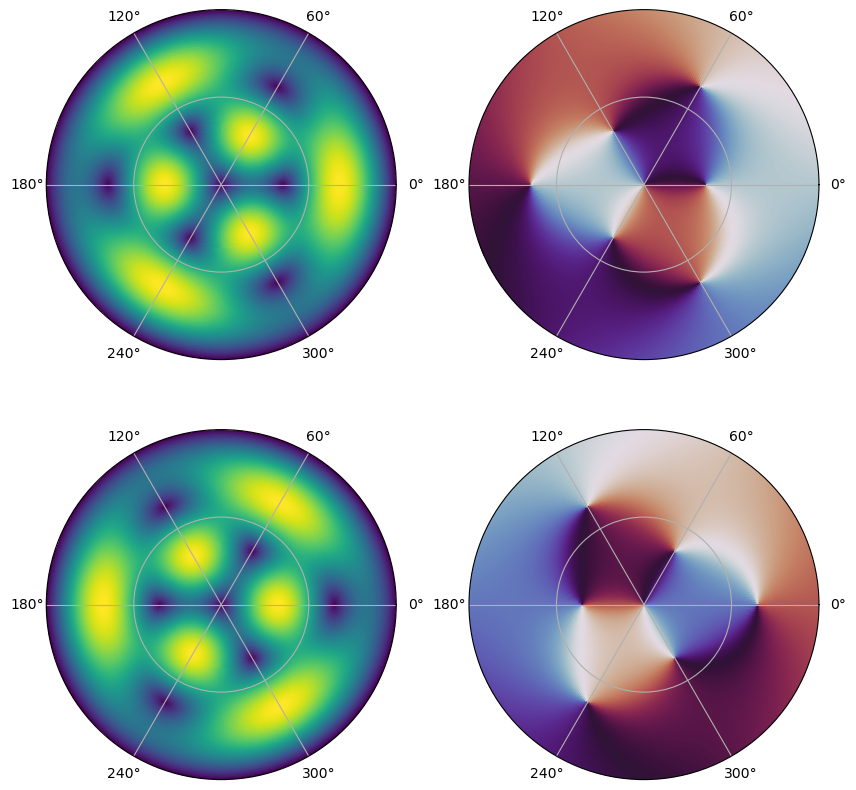

In [ ]:
theta = np.linspace(0, np.pi, 400)
phi = np.linspace(0, 2 * np.pi, 400)
theta, phi = np.meshgrid(theta, phi)

dxy = sph_harm_y(2, 2, theta, phi) + sph_harm_y(2, -2, theta, phi)
dx_y2 = (sph_harm_y(2, 2, theta, phi) - sph_harm_y(2, -2, theta, phi)) * 1j
dy = (sph_harm_y(2, 1, theta, phi) + sph_harm_y(2, -1, theta, phi)) * 1j
dx = sph_harm_y(2, 1, theta, phi) - sph_harm_y(2, -1, theta, phi)

m1 = np.diag([np.exp(1j * np.pi / 3), np.exp(-1j * np.pi / 3), 1, 1])

m2 = np.matrix(
    [
        [1j, -1, 1, 1j],
        [-1j, -1, 1, -1j],
        [-1j, 1, 1, 1j],
        [1j, 1, 1, -1j],
    ]
) / np.sqrt(4)

row = m1 @ m2

print(row.shape)


def orb(a):
    return (row[a, 0] * dxy + row[a, 1] * dx_y2) + (row[a, 2] * dy + row[a, 3] * dx)


o1 = orb(1)
o2 = orb(1)
o3 = orb(2)
o4 = orb(3)


# polar colormap

fig, ax = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(10, 10))

ax[0, 0].pcolormesh(phi, theta, np.abs(o1), shading="auto")
ax[0, 1].pcolormesh(phi, theta, np.angle(o1), shading="auto", cmap="twilight")
ax[1, 0].pcolormesh(phi, theta, np.abs(o3), shading="auto")
ax[1, 1].pcolormesh(phi, theta, np.angle(o3), shading="auto", cmap="twilight")

for ax in ax.flatten():
    ax.set_xticks([0, np.pi / 3, 2 * np.pi / 3, np.pi, 4 * np.pi / 3, 5 * np.pi / 3])
    ax.set_yticks([np.pi / 2])
    ax.set_yticklabels([])

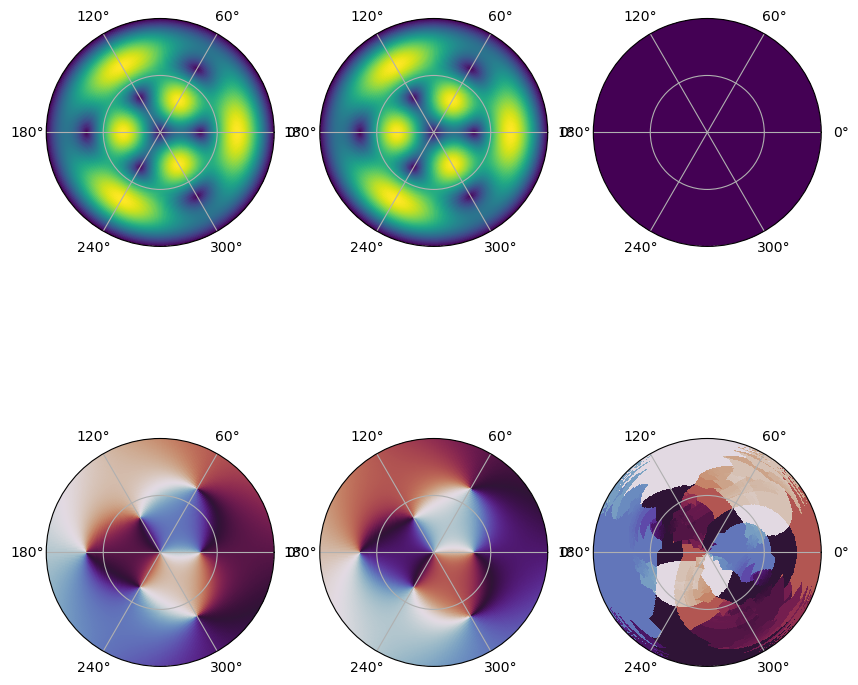

In [ ]:
angle = np.pi * 2 / 3

rotated_1 = o1
rotated_2 = np.cos(angle * 3 / 2) * o1 + np.sin(angle * 3 / 2) * o3
rotated_2

fig, ax = plt.subplots(2, 3, subplot_kw={"projection": "polar"}, figsize=(10, 10))

ax[0, 0].pcolormesh(
    phi + angle,
    theta,
    np.abs(rotated_1),
    shading="auto",
    clim=(0, np.max(np.abs(rotated_1))),
)
ax[1, 0].pcolormesh(
    phi + angle,
    theta,
    np.angle(rotated_1),
    shading="auto",
    cmap="twilight",
    clim=(-np.pi, np.pi),
)

ax[0, 1].pcolormesh(
    phi, theta, np.abs(rotated_2), shading="auto", clim=(0, np.max(np.abs(rotated_1)))
)
ax[1, 1].pcolormesh(
    phi,
    theta,
    np.angle(rotated_2),
    shading="auto",
    cmap="twilight",
    clim=(-np.pi, np.pi),
)

ax[0, 2].pcolormesh(
    phi,
    theta,
    np.abs(rotated_2 + rotated_1),
    shading="auto",
    clim=(0, np.max(np.abs(rotated_1))),
)
ax[1, 2].pcolormesh(
    phi,
    theta,
    np.angle(rotated_2 + rotated_1),
    shading="auto",
    cmap="twilight",
    clim=(-np.pi, np.pi),
)

for ax in ax.flatten():
    ax.set_xticks([0, np.pi / 3, 2 * np.pi / 3, np.pi, 4 * np.pi / 3, 5 * np.pi / 3])
    ax.set_yticks([np.pi / 2])
    ax.set_yticklabels([])

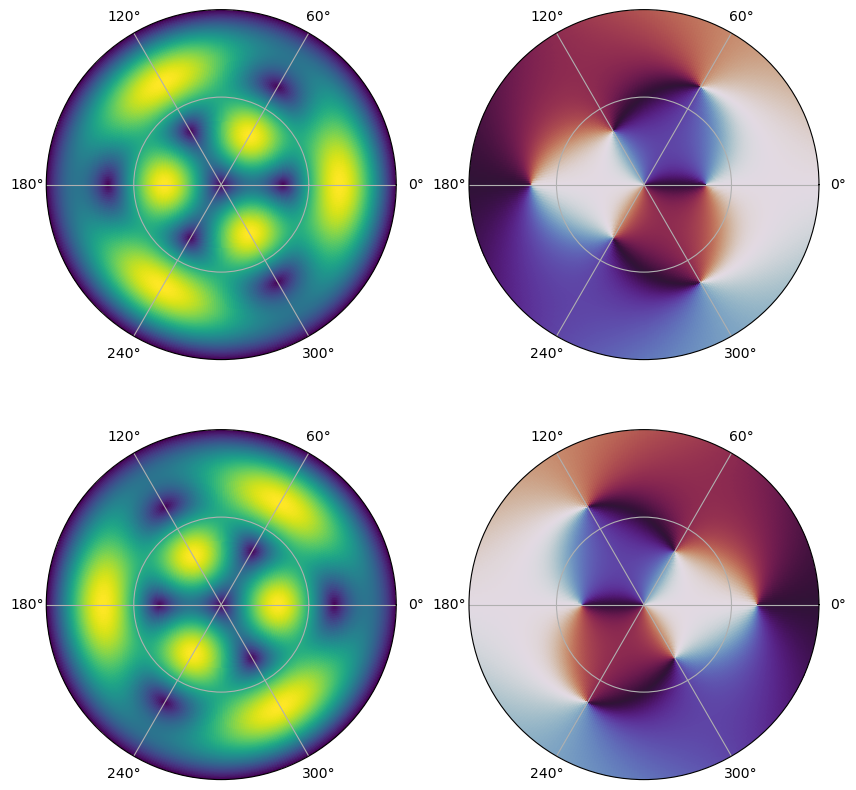

In [586]:
p1 = sph_harm_y(2, -1, theta, phi) - sph_harm_y(2, 2, theta, phi)
p3 = sph_harm_y(2, 1, theta, phi) - sph_harm_y(2, -2, theta, phi)
q1 = p1
q3 = p3


fig, ax = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(10, 10))

ax[0, 0].pcolormesh(phi, theta, np.abs(q1), shading="auto")
ax[0, 1].pcolormesh(phi, theta, np.angle(q1), shading="auto", cmap="twilight")
ax[1, 0].pcolormesh(phi, theta, np.abs(q3), shading="auto")
ax[1, 1].pcolormesh(phi, theta, np.angle(q3), shading="auto", cmap="twilight")

for ax in ax.flatten():
    ax.set_xticks([0, np.pi / 3, 2 * np.pi / 3, np.pi, 4 * np.pi / 3, 5 * np.pi / 3])
    ax.set_yticks([np.pi / 2])
    ax.set_yticklabels([])